In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LogisticRegression,
    LinearRegression
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier
)

from sklearn.neighbors import (
    KNeighborsClassifier
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

In [3]:
import pandas as pd
df_original=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/CVD Dataset.csv")
df=df_original.copy()
df.head()

,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,F,32.0,69.1,1.71,23.6,86.2,125/79,248.0,78.0,111.0,...,Low,N,171.0,0.504,125.0,79.0,Elevated,140.0,17.93,INTERMEDIARY
1,F,55.0,118.7,1.69,41.6,82.5,139/70,162.0,50.0,135.0,...,High,Y,169.0,0.488,139.0,70.0,Hypertension Stage 1,82.0,20.51,HIGH
2,M,NaN,NaN,1.83,26.9,106.7,104/77,103.0,73.0,114.0,...,High,Y,183.0,0.583,104.0,77.0,Normal,0.0,12.64,INTERMEDIARY
3,M,44.0,108.3,1.80,33.4,96.6,140/83,134.0,46.0,91.0,...,High,Y,NaN,0.537,140.0,83.0,Hypertension Stage 1,58.0,16.36,INTERMEDIARY
4,F,32.0,99.5,1.86,28.8,102.7,144/83,146.0,64.0,141.0,...,High,N,186.0,0.552,144.0,83.0,Hypertension Stage 1,52.0,17.88,INTERMEDIARY


In [4]:
df.shape

(1529, 22)

In [5]:
df.columns

Index(['Sex', 'Age', 'Weight (kg)', 'Height (m)', 'BMI',
       'Abdominal Circumference (cm)', 'Blood Pressure (mmHg)',
       'Total Cholesterol (mg/dL)', 'HDL (mg/dL)',
       'Fasting Blood Sugar (mg/dL)', 'Smoking Status', 'Diabetes Status',
       'Physical Activity Level', 'Family History of CVD', 'Height (cm)',
       'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP',
       'Blood Pressure Category', 'Estimated LDL (mg/dL)', 'CVD Risk Score',
       'CVD Risk Level'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1529 entries, 0 to 1528
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sex                           1529 non-null   object 
 1   Age                           1451 non-null   float64
 2   Weight (kg)                   1448 non-null   float64
 3   Height (m)                    1462 non-null   float64
 4   BMI                           1465 non-null   float64
 5   Abdominal Circumference (cm)  1462 non-null   float64
 6   Blood Pressure (mmHg)         1529 non-null   object 
 7   Total Cholesterol (mg/dL)     1456 non-null   float64
 8   HDL (mg/dL)                   1449 non-null   float64
 9   Fasting Blood Sugar (mg/dL)   1462 non-null   float64
 10  Smoking Status                1529 non-null   object 
 11  Diabetes Status               1529 non-null   object 
 12  Physical Activity Level       1529 non-null   object 
 13  Fam

In [7]:
df.isnull().sum()

,0
Sex,0
Age,78
Weight (kg),81
Height (m),67
BMI,64
Abdominal Circumference (cm),67
Blood Pressure (mmHg),0
Total Cholesterol (mg/dL),73
HDL (mg/dL),80
Fasting Blood Sugar (mg/dL),67


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1451.0,47.025500,12.421063,25.000,37.000,46.0000,55.00000,79.000
Weight (kg),1448.0,85.917427,21.012580,50.100,67.050,86.6145,105.00000,120.000
Height (m),1462.0,1.754111,0.113090,1.502,1.660,1.7550,1.84550,2.000
BMI,1465.0,28.465997,7.038685,15.000,22.629,28.1590,34.00000,46.200
Abdominal Circumference (cm),1462.0,91.773214,12.823573,70.000,80.500,91.6000,102.26900,119.996
Total Cholesterol (mg/dL),1456.0,198.539148,57.794099,100.000,150.000,197.0000,249.00000,300.000
HDL (mg/dL),1449.0,56.197378,16.066754,30.000,42.000,56.0000,70.00000,89.000
Fasting Blood Sugar (mg/dL),1462.0,117.485636,30.289174,70.000,92.000,115.0000,138.00000,198.000
Height (cm),1455.0,175.390600,11.251527,150.000,166.000,175.6940,184.20850,199.960
Waist-to-Height Ratio,1450.0,0.525727,0.081213,0.360,0.460,0.5220,0.58375,0.787


In [9]:
(df['Estimated LDL (mg/dL)']<0).sum()

np.int64(13)

In [10]:
(df['Estimated LDL (mg/dL)']<30).sum()

np.int64(101)

In [11]:
df[df['Estimated LDL (mg/dL)']<0]

,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
58,F,44.0,101.500,1.690,35.500,91.500,98/73,103.0,74.0,93.0,...,Moderate,N,169.000,0.541,98.0,73.0,Normal,-1.0,14.060,LOW
120,F,60.0,54.800,1.770,17.500,81.200,108/81,108.0,80.0,108.0,...,Moderate,N,177.000,0.459,108.0,81.0,Hypertension Stage 1,-2.0,11.060,INTERMEDIARY
654,F,38.0,58.600,1.720,19.800,102.000,117/92,102.0,78.0,141.0,...,High,N,NaN,0.593,117.0,92.0,Hypertension Stage 2,-6.0,NaN,LOW
761,M,51.0,72.800,1.810,22.200,NaN,126/82,101.0,78.0,76.0,...,Moderate,Y,181.000,0.508,126.0,82.0,Hypertension Stage 1,-7.0,12.760,INTERMEDIARY
1086,M,58.0,53.317,1.913,28.419,110.331,172/108,100.0,88.0,106.0,...,Moderate,N,191.253,0.577,172.0,108.0,Hypertension Stage 2,-18.0,16.284,HIGH
1117,M,61.0,61.983,1.787,19.674,NaN,92/93,104.0,76.0,137.0,...,High,Y,178.652,0.532,92.0,93.0,Hypertension Stage 2,-2.0,NaN,LOW
1132,M,49.0,83.065,1.971,28.154,92.423,103/81,104.0,89.0,71.0,...,Low,Y,197.127,0.469,103.0,81.0,Hypertension Stage 1,-15.0,12.861,INTERMEDIARY
1270,F,65.0,112.076,1.883,37.784,83.952,141/81,107.0,80.0,161.0,...,High,Y,188.311,0.446,141.0,81.0,Hypertension Stage 1,-3.0,16.747,HIGH
1275,F,26.0,66.394,1.860,27.704,91.595,165/101,106.0,78.0,103.0,...,High,Y,185.957,0.493,165.0,101.0,Hypertension Stage 2,-2.0,NaN,LOW
1344,M,NaN,61.262,1.712,23.333,98.601,129/85,103.0,83.0,127.0,...,Moderate,Y,171.218,0.576,129.0,85.0,Hypertension Stage 1,-10.0,15.177,HIGH


In [12]:
import numpy as np
df.loc[df['Estimated LDL (mg/dL)']<0,'Estimated LDL (mg/dL)']=np.nan
(df['Estimated LDL (mg/dL)']<0).sum()

np.int64(0)

In [13]:
df['CVD Risk Level'].value_counts()

,count
CVD Risk Level,
HIGH,728
INTERMEDIARY,581
LOW,220


In [14]:
df[['CVD Risk Score','CVD Risk Level']].head(10)

,CVD Risk Score,CVD Risk Level
0,17.93,INTERMEDIARY
1,20.51,HIGH
2,12.64,INTERMEDIARY
3,16.36,INTERMEDIARY
4,17.88,INTERMEDIARY
5,16.96,HIGH
6,17.60,INTERMEDIARY
7,18.11,HIGH
8,15.25,INTERMEDIARY
9,17.91,INTERMEDIARY


In [15]:
df[['Blood Pressure (mmHg)','Systolic BP','Diastolic BP']].head(10)

,Blood Pressure (mmHg),Systolic BP,Diastolic BP
0,125/79,125.0,79.0
1,139/70,139.0,70.0
2,104/77,104.0,77.0
3,140/83,140.0,83.0
4,144/83,144.0,83.0
5,142/90,142.0,90.0
6,96/63,96.0,63.0
7,115/73,115.0,73.0
8,107/95,NaN,95.0
9,133/83,133.0,83.0


In [16]:
df.groupby('CVD Risk Level')['CVD Risk Score'].describe()

,count,mean,std,min,25%,50%,75%,max
CVD Risk Level,,,,,,,,
HIGH,697.0,17.611323,2.209007,10.89,16.1500,17.620,19.2250,24.170
INTERMEDIARY,559.0,16.133444,2.345940,10.53,14.4490,16.010,17.6625,23.510
LOW,203.0,17.006419,2.732331,10.86,14.6725,16.921,18.9055,23.797


In [17]:
bp_split=df['Blood Pressure (mmHg)'].str.split('/',expand=True)
bp_split[0]=bp_split[0].astype(float)
bp_split[1]=bp_split[1].astype(float)

In [18]:
(df['Systolic BP']!=bp_split[0]).sum()

np.int64(71)

In [19]:
(df['Diastolic BP']!=bp_split[1]).sum()

np.int64(82)

In [20]:
((df['Systolic BP'].notna())&(df['Systolic BP'] !=bp_split[0])).sum()

np.int64(0)

In [21]:
((df['Diastolic BP'].notna()) & (df['Diastolic BP'] != bp_split[1])).sum()

np.int64(0)

In [22]:
df['Systolic BP']=df['Systolic BP'].fillna(bp_split[0])
df['Diastolic BP']=df['Diastolic BP'].fillna(bp_split[1])
df[['Systolic BP','Diastolic BP']].isnull().sum()

,0
Systolic BP,0
Diastolic BP,0


In [23]:
((df['Height (m)'].notna())& (df['Height (cm)'].notna()) & ((df['Height (m)']*100).round(1) != df['Height (cm)'].round(1))).sum()

np.int64(2)

In [24]:
df[
    (df['Height (m)'].notna()) &
    (df['Height (cm)'].notna()) &
    ((df['Height (m)']*100).round(1) !=df['Height (cm)'].round(1))][['Height (m)','Height (cm)']].head(20)

,Height (m),Height (cm)
1185,1.657,165.65
1393,1.827,182.65


In [25]:
df = df.drop(columns=['Blood Pressure (mmHg)','Height (cm)'], errors='ignore')

In [26]:
df.shape

(1529, 20)

In [27]:
df.columns

Index(['Sex', 'Age', 'Weight (kg)', 'Height (m)', 'BMI',
       'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)',
       'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Smoking Status',
       'Diabetes Status', 'Physical Activity Level', 'Family History of CVD',
       'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP',
       'Blood Pressure Category', 'Estimated LDL (mg/dL)', 'CVD Risk Score',
       'CVD Risk Level'],
      dtype='object')

In [28]:
df.isnull().sum()

,0
Sex,0
Age,78
Weight (kg),81
Height (m),67
BMI,64
Abdominal Circumference (cm),67
Total Cholesterol (mg/dL),73
HDL (mg/dL),80
Fasting Blood Sugar (mg/dL),67
Smoking Status,0


In [29]:
df[
    df['BMI'].isna() &
    df['Weight (kg)'].notna() &
    df['Height (m)'].notna()
].shape

(57, 20)

In [30]:
df.loc[
    df['BMI'].isna(),'BMI']=df['Weight (kg)']/(df['Height (m)']**2)
df['BMI'].isna().sum()

np.int64(7)

In [31]:
df.loc[
    df['Waist-to-Height Ratio'].isna(),
    'Waist-to-Height Ratio'
] = df['Abdominal Circumference (cm)'] / (df['Height (m)']*100)

df['Waist-to-Height Ratio'].isna().sum()

np.int64(5)

In [32]:
df.loc[
    df['Abdominal Circumference (cm)'].isna(),
    'Abdominal Circumference (cm)'
]= df['Waist-to-Height Ratio']*(df['Height (m)']*100)
df['Abdominal Circumference (cm)'].isna().sum()

np.int64(4)

In [33]:
df.loc[
    df['Height (m)'].isna(),
    'Height (m)'
] = (df['Abdominal Circumference (cm)'] / df['Waist-to-Height Ratio']) / 100

df['Height (m)'].isna().sum()

np.int64(5)

In [34]:
df.loc[
    df['BMI'].isna(),
    'BMI'
] = df['Weight (kg)'] / (df['Height (m)']**2)

df['BMI'].isna().sum()

np.int64(4)

In [35]:
df.loc[
    df['Weight (kg)'].isna(),
    'Weight (kg)'
] = df['BMI'] * (df['Height (m)']**2)

df['Weight (kg)'].isna().sum()

np.int64(6)

In [36]:
df.loc[
    df['Height (m)'].isna(),
    'Height (m)'
] = (df['Weight (kg)'] / df['BMI'])**0.5

df['Height (m)'].isna().sum()

np.int64(2)

In [37]:
df.isna().sum()

,0
Sex,0
Age,78
Weight (kg),6
Height (m),2
BMI,4
Abdominal Circumference (cm),4
Total Cholesterol (mg/dL),73
HDL (mg/dL),80
Fasting Blood Sugar (mg/dL),67
Smoking Status,0


In [38]:
df.loc[
    df['Waist-to-Height Ratio'].isna(),
    'Waist-to-Height Ratio'
] = df['Abdominal Circumference (cm)'] / (df['Height (m)']*100)

df['Waist-to-Height Ratio'].isna().sum()

np.int64(3)

In [39]:
df.loc[
    df['Abdominal Circumference (cm)'].isna(),
    'Abdominal Circumference (cm)'
] = df['Waist-to-Height Ratio'] * (df['Height (m)']*100)

df['Abdominal Circumference (cm)'].isna().sum()

np.int64(3)

In [40]:
numeric_cols = df.select_dtypes(include='number').columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)
df.isna().sum()

,0
Sex,0
Age,0
Weight (kg),0
Height (m),0
BMI,0
Abdominal Circumference (cm),0
Total Cholesterol (mg/dL),0
HDL (mg/dL),0
Fasting Blood Sugar (mg/dL),0
Smoking Status,0


In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
df = df.drop(columns=['Blood Pressure Category'])

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1529 entries, 0 to 1528
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sex                           1529 non-null   object 
 1   Age                           1529 non-null   float64
 2   Weight (kg)                   1529 non-null   float64
 3   Height (m)                    1529 non-null   float64
 4   BMI                           1529 non-null   float64
 5   Abdominal Circumference (cm)  1529 non-null   float64
 6   Total Cholesterol (mg/dL)     1529 non-null   float64
 7   HDL (mg/dL)                   1529 non-null   float64
 8   Fasting Blood Sugar (mg/dL)   1529 non-null   float64
 9   Smoking Status                1529 non-null   object 
 10  Diabetes Status               1529 non-null   object 
 11  Physical Activity Level       1529 non-null   object 
 12  Family History of CVD         1529 non-null   object 
 13  Wai

In [44]:
df.shape

(1529, 19)

In [45]:
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].unique())

Sex ['F' 'M']
Smoking Status ['N' 'Y']
Diabetes Status ['Y' 'N']
Physical Activity Level ['Low' 'High' 'Moderate']
Family History of CVD ['N' 'Y']
CVD Risk Level ['INTERMEDIARY' 'HIGH' 'LOW']


In [46]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

df['Sex'] = df['Sex'].map({'F':0, 'M':1})
df['Smoking Status'] = df['Smoking Status'].map({'N':0, 'Y':1})
df['Diabetes Status'] = df['Diabetes Status'].map({'N':0, 'Y':1})
df['Family History of CVD'] = df['Family History of CVD'].map({'N':0, 'Y':1})

df['Physical Activity Level'] = df['Physical Activity Level'].map({
    'Low':0,
    'Moderate':1,
    'High':2
})

df['CVD Risk Level'] = df['CVD Risk Level'].map({
    'LOW':0,
    'INTERMEDIARY':1,
    'HIGH':2
})

In [47]:
df.isnull().sum()

,0
Sex,0
Age,0
Weight (kg),0
Height (m),0
BMI,0
Abdominal Circumference (cm),0
Total Cholesterol (mg/dL),0
HDL (mg/dL),0
Fasting Blood Sugar (mg/dL),0
Smoking Status,0


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1529 entries, 0 to 1528
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sex                           1529 non-null   int64  
 1   Age                           1529 non-null   float64
 2   Weight (kg)                   1529 non-null   float64
 3   Height (m)                    1529 non-null   float64
 4   BMI                           1529 non-null   float64
 5   Abdominal Circumference (cm)  1529 non-null   float64
 6   Total Cholesterol (mg/dL)     1529 non-null   float64
 7   HDL (mg/dL)                   1529 non-null   float64
 8   Fasting Blood Sugar (mg/dL)   1529 non-null   float64
 9   Smoking Status                1529 non-null   int64  
 10  Diabetes Status               1529 non-null   int64  
 11  Physical Activity Level       1529 non-null   int64  
 12  Family History of CVD         1529 non-null   int64  
 13  Wai

In [49]:
df.head(20)

,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Smoking Status,Diabetes Status,Physical Activity Level,Family History of CVD,Waist-to-Height Ratio,Systolic BP,Diastolic BP,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,0,32.0,69.100000,1.710000,23.6,86.20,248.0,78.0,111.0,0,1,0,0,0.504000,125.0,79.0,140.0,17.93,1
1,0,55.0,118.700000,1.690000,41.6,82.50,162.0,50.0,135.0,1,1,2,1,0.488000,139.0,70.0,82.0,20.51,2
2,1,46.0,90.085410,1.830000,26.9,106.70,103.0,73.0,114.0,0,0,2,1,0.583000,104.0,77.0,0.0,12.64,1
3,1,44.0,108.300000,1.800000,33.4,96.60,134.0,46.0,91.0,0,0,2,1,0.537000,140.0,83.0,58.0,16.36,1
4,0,32.0,99.500000,1.860000,28.8,102.70,146.0,64.0,141.0,1,1,2,0,0.552000,144.0,83.0,52.0,17.88,1
5,0,58.0,117.900000,1.870000,33.7,81.40,156.0,67.0,82.0,1,0,1,1,0.435000,142.0,90.0,59.0,16.96,2
6,1,33.0,117.900000,1.820000,35.6,74.80,184.0,66.0,87.0,0,1,0,0,0.411000,96.0,63.0,88.0,17.60,1
7,1,55.0,100.100000,1.740000,33.1,96.60,287.0,40.0,96.0,1,0,1,0,0.555000,115.0,73.0,217.0,18.11,2
8,0,37.0,110.100000,1.860000,31.8,92.40,177.0,68.0,70.0,1,0,2,0,0.497000,107.0,95.0,79.0,15.25,1
9,0,58.0,97.600000,1.860000,28.2,74.60,281.0,68.0,126.0,0,0,1,0,0.401000,133.0,83.0,183.0,17.91,1


In [50]:
X_score = df.drop(
    ['CVD Risk Score','CVD Risk Level'],
    axis=1
)

y_score = df['CVD Risk Score']

print(X_score.shape)
print(y_score.shape)

(1529, 17)
(1529,)


In [51]:
X_level = df.drop(
    ['CVD Risk Level'],
    axis=1
)

y_level = df['CVD Risk Level']

print(X_level.shape)
print(y_level.shape)

(1529, 18)
(1529,)


In [63]:
from sklearn.model_selection import train_test_split

X_train_score, X_test_score, y_train_score, y_test_score = train_test_split(
    X_score,
    y_score,
    test_size=0.2,
    random_state=42
)

In [53]:
df.corr()['CVD Risk Level'].sort_values(ascending=False)

,CVD Risk Level
CVD Risk Level,1.000000
Family History of CVD,0.183542
CVD Risk Score,0.171306
Smoking Status,0.164735
Diabetes Status,0.162816
Estimated LDL (mg/dL),0.161060
BMI,0.153303
Weight (kg),0.128019
Total Cholesterol (mg/dL),0.123749
Age,0.010497


In [54]:
print(
    X_score.isnull().sum()
)

Sex                             0
Age                             0
Weight (kg)                     0
Height (m)                      0
BMI                             0
Abdominal Circumference (cm)    0
Total Cholesterol (mg/dL)       0
HDL (mg/dL)                     0
Fasting Blood Sugar (mg/dL)     0
Smoking Status                  0
Diabetes Status                 0
Physical Activity Level         0
Family History of CVD           0
Waist-to-Height Ratio           0
Systolic BP                     0
Diastolic BP                    0
Estimated LDL (mg/dL)           0
dtype: int64


In [59]:
from sklearn.linear_model import LinearRegression

score_model = LinearRegression()

score_model.fit(
    X_train_score,
    y_train_score
)

print("Risk score model trained")

Risk score model trained


In [65]:
X_train_score, X_test_score, y_train_score, y_test_score = train_test_split(
    X_score,
    y_score,
    test_size=0.2,
    random_state=42
)

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X_level,
    y_level,
    test_size=0.2,
    random_state=42,
    stratify=y_level
)

In [71]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


print(X_train_scaled.shape)

(1223, 18)


In [72]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred_lr))

0.6372549019607843


In [73]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.11      0.02      0.04        44
           1       0.62      0.66      0.64       116
           2       0.68      0.81      0.74       146

    accuracy                           0.64       306
   macro avg       0.47      0.50      0.47       306
weighted avg       0.57      0.64      0.60       306



In [74]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print(accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

0.5882352941176471
              precision    recall  f1-score   support

           0       0.34      0.34      0.34        44
           1       0.57      0.57      0.57       116
           2       0.67      0.68      0.68       146

    accuracy                           0.59       306
   macro avg       0.53      0.53      0.53       306
weighted avg       0.59      0.59      0.59       306



In [75]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

0.6274509803921569
              precision    recall  f1-score   support

           0       0.36      0.11      0.17        44
           1       0.61      0.59      0.60       116
           2       0.66      0.82      0.73       146

    accuracy                           0.63       306
   macro avg       0.54      0.50      0.50       306
weighted avg       0.60      0.63      0.60       306



In [76]:
import pandas as pd

feature_importance = pd.Series(
    dt.feature_importances_,
    index=X_level.columns
).sort_values(ascending=False)

print(feature_importance)

CVD Risk Score                  0.129763
Age                             0.102650
HDL (mg/dL)                     0.093620
Fasting Blood Sugar (mg/dL)     0.076413
Systolic BP                     0.076028
Height (m)                      0.061864
Weight (kg)                     0.057628
Abdominal Circumference (cm)    0.052979
Smoking Status                  0.046928
Diastolic BP                    0.045251
BMI                             0.045216
Estimated LDL (mg/dL)           0.041823
Waist-to-Height Ratio           0.040877
Family History of CVD           0.037775
Physical Activity Level         0.035125
Total Cholesterol (mg/dL)       0.030896
Diabetes Status                 0.023372
Sex                             0.001792
dtype: float64


In [77]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print(accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

0.6111111111111112
              precision    recall  f1-score   support

           0       0.33      0.14      0.19        44
           1       0.57      0.56      0.56       116
           2       0.67      0.79      0.73       146

    accuracy                           0.61       306
   macro avg       0.52      0.50      0.49       306
weighted avg       0.58      0.61      0.59       306



In [78]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_dt))

[[15 16 13]
 [15 66 35]
 [14 33 99]]


In [80]:
import joblib

joblib.dump(dt, 'cvd_model.pkl')

['cvd_model.pkl']

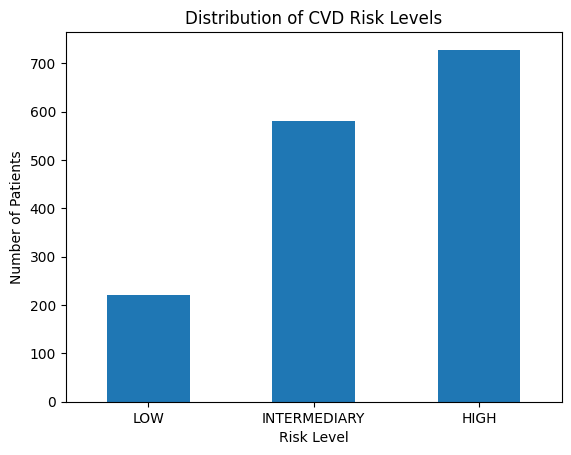

In [81]:
risk_labels = {
    0:'LOW',
    1:'INTERMEDIARY',
    2:'HIGH'
}

counts = df['CVD Risk Level'].value_counts().sort_index()
counts.index = counts.index.map(risk_labels)

counts.plot(kind='bar')

plt.title('Distribution of CVD Risk Levels')
plt.xlabel('Risk Level')
plt.ylabel('Number of Patients')

plt.xticks(rotation=0)

plt.show()

In [82]:
risk_labels = {
    0:'LOW',
    1:'INTERMEDIARY',
    2:'HIGH'
}


df_plot = df.copy()


df_plot['Risk Label'] = df_plot[
    'CVD Risk Level'
].map(
    risk_labels
)

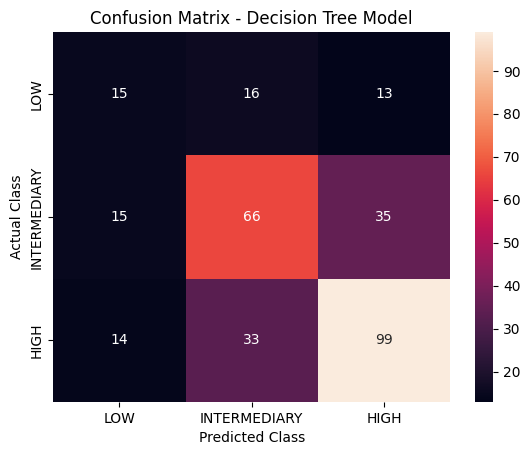

In [83]:
cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['LOW','INTERMEDIARY','HIGH'],
    yticklabels=['LOW','INTERMEDIARY','HIGH']
)

plt.title('Confusion Matrix - Decision Tree Model')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.show()

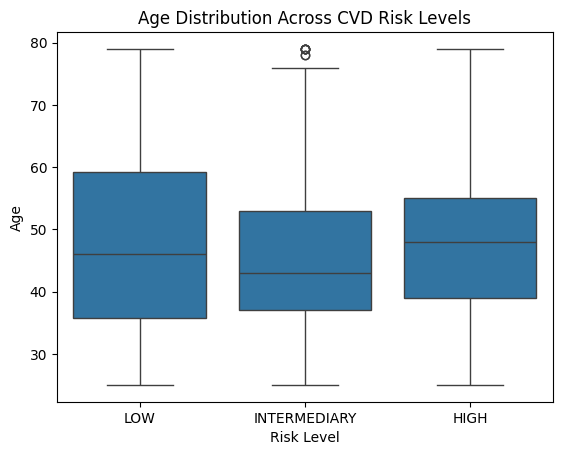

In [84]:
sns.boxplot(
    x='Risk Label',
    y='Age',
    data=df_plot,
    order=['LOW','INTERMEDIARY','HIGH']
)

plt.title('Age Distribution Across CVD Risk Levels')
plt.xlabel('Risk Level')
plt.ylabel('Age')

plt.show()

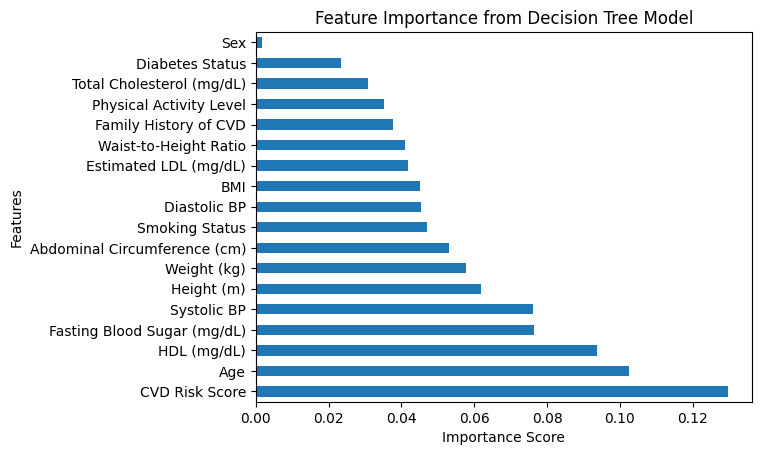

In [85]:
feature_importance.plot(kind='barh')

plt.title('Feature Importance from Decision Tree Model')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.show()

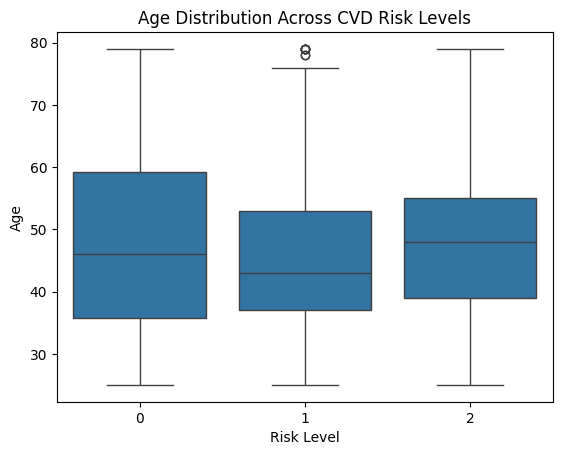

In [86]:
sns.boxplot(
    x='CVD Risk Level',
    y='Age',
    data=df
)

plt.title('Age Distribution Across CVD Risk Levels')
plt.xlabel('Risk Level')
plt.ylabel('Age')

plt.show()

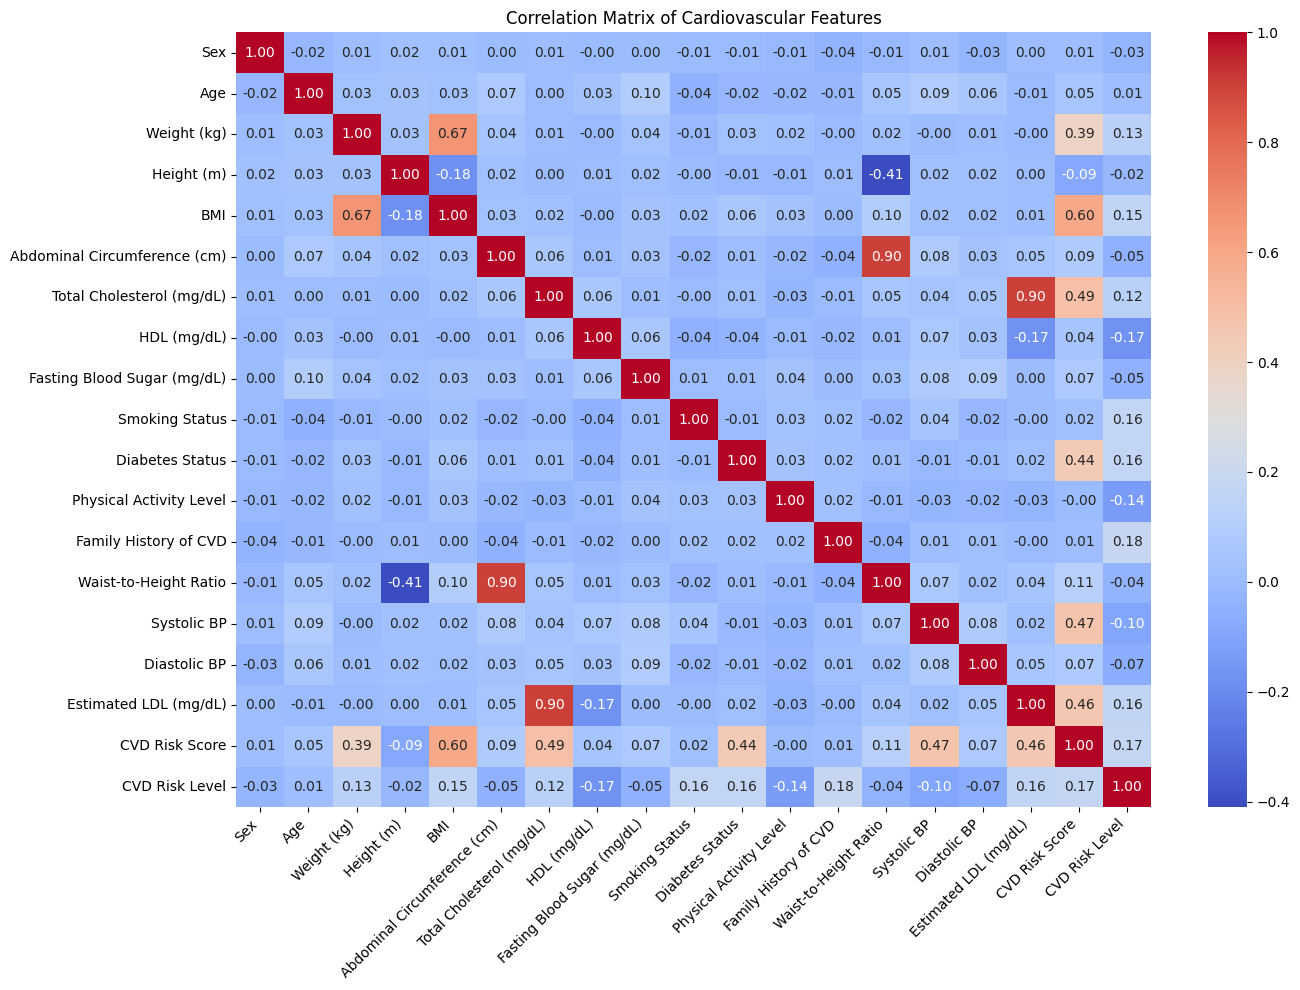

In [87]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix of Cardiovascular Features')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

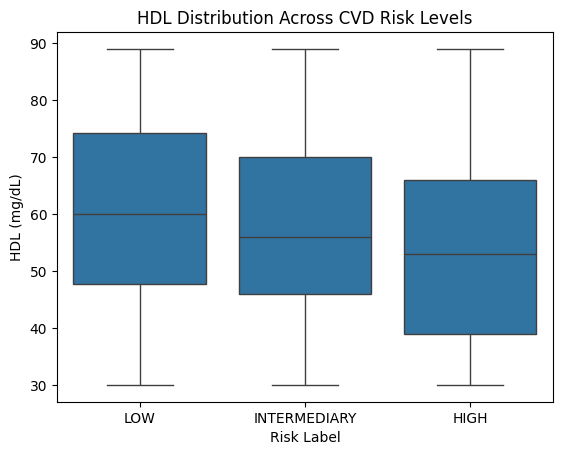

In [88]:
sns.boxplot(
    x='Risk Label',
    y='HDL (mg/dL)',
    data=df_plot,
    order=['LOW','INTERMEDIARY','HIGH']
)

plt.title('HDL Distribution Across CVD Risk Levels')
plt.show()

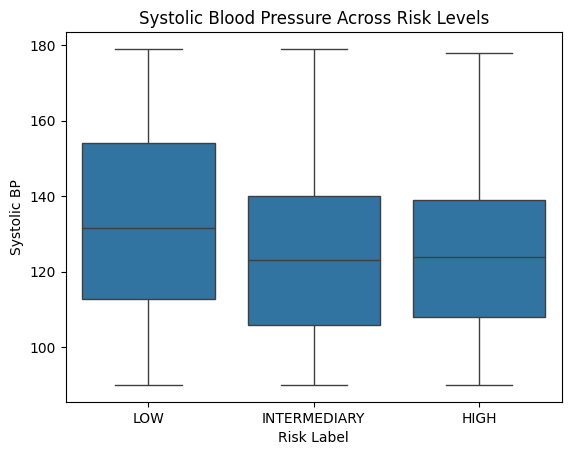

In [89]:
sns.boxplot(
    x='Risk Label',
    y='Systolic BP',
    data=df_plot,
    order=['LOW','INTERMEDIARY','HIGH']
)

plt.title('Systolic Blood Pressure Across Risk Levels')
plt.show()

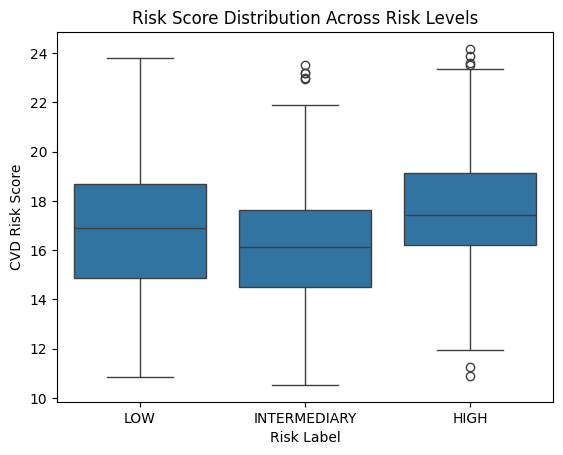

In [90]:
sns.boxplot(
    x='Risk Label',
    y='CVD Risk Score',
    data=df_plot,
    order=['LOW','INTERMEDIARY','HIGH']
)

plt.title('Risk Score Distribution Across Risk Levels')
plt.show()

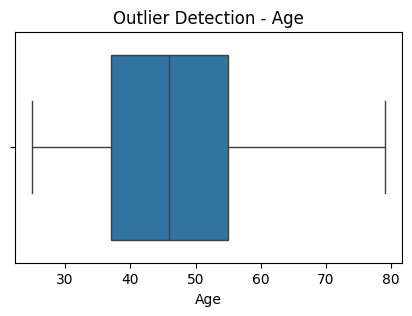

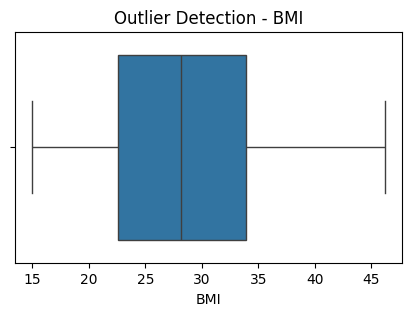

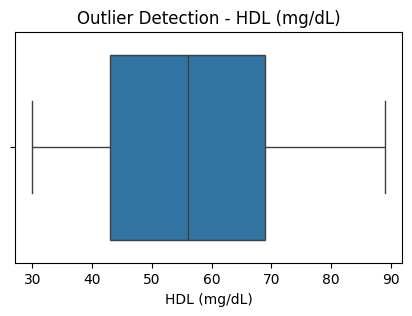

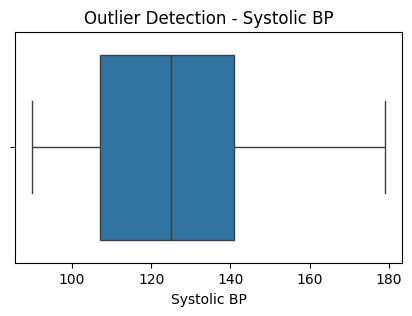

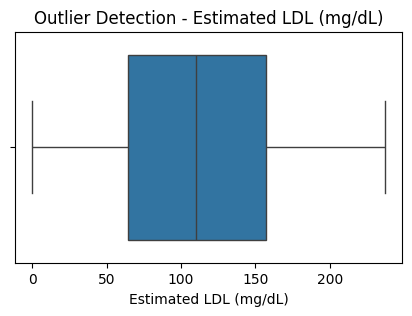

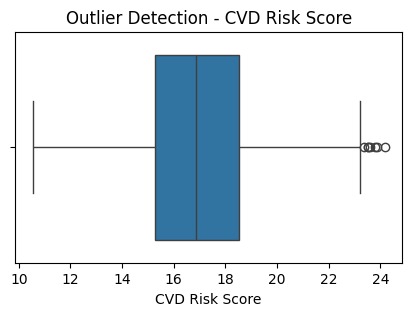

In [91]:
numeric_cols = [
    'Age',
    'BMI',
    'HDL (mg/dL)',
    'Systolic BP',
    'Estimated LDL (mg/dL)',
    'CVD Risk Score'
]

for col in numeric_cols:
    plt.figure(figsize=(5,3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f'Outlier Detection - {col}')

    plt.show()

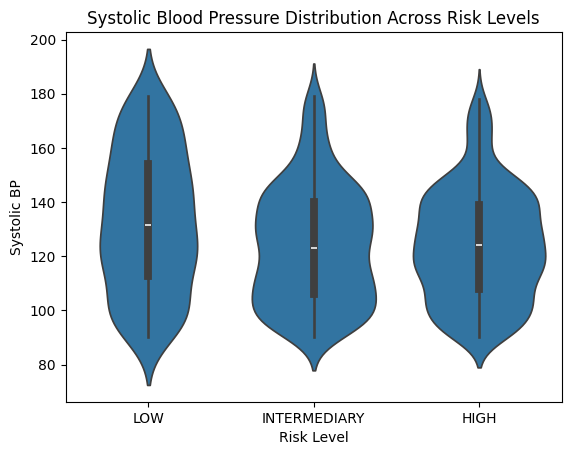

In [92]:
sns.violinplot(
    x='Risk Label',
    y='Systolic BP',
    data=df_plot,
    order=['LOW','INTERMEDIARY','HIGH']
)

plt.title('Systolic Blood Pressure Distribution Across Risk Levels')
plt.xlabel('Risk Level')
plt.ylabel('Systolic BP')

plt.show()

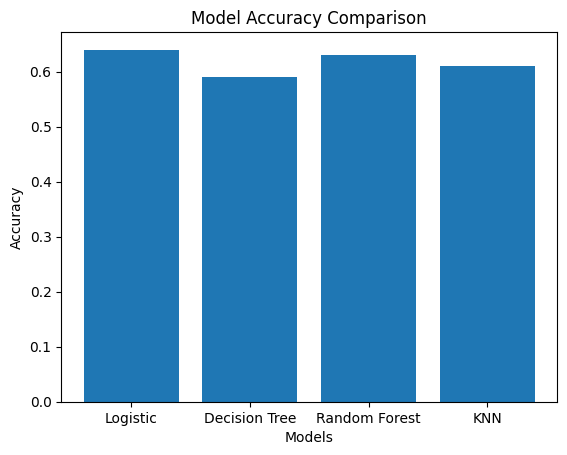

In [95]:
model_names = [
    'Logistic',
    'Decision Tree',
    'Random Forest',
    'KNN'
]

accuracies = [
    0.64,
    0.59,
    0.63,
    0.61
]

plt.bar(model_names, accuracies)

plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')

plt.show()


In [96]:
import joblib

joblib.dump(score_model,'score_model.pkl')

joblib.dump(dt,'cvd_model.pkl')

print("Both models saved")

Both models saved


In [97]:
print(X_level.columns)

Index(['Sex', 'Age', 'Weight (kg)', 'Height (m)', 'BMI',
       'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)',
       'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Smoking Status',
       'Diabetes Status', 'Physical Activity Level', 'Family History of CVD',
       'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP',
       'Estimated LDL (mg/dL)', 'CVD Risk Score'],
      dtype='object')
